# EJERCICIO DE REGRESION

## **Cargar el dataset**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

calories_test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Regresion/test.csv')
calories_train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Regresion/train.csv')
calories_test



,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,750000,male,45,177.0,81.0,7.0,87.0,39.8
1,750001,male,26,200.0,97.0,20.0,101.0,40.5
2,750002,female,29,188.0,85.0,16.0,102.0,40.4
3,750003,female,39,172.0,73.0,20.0,107.0,40.6
4,750004,female,30,173.0,67.0,16.0,94.0,40.5
...,...,...,...,...,...,...,...,...
249995,999995,female,56,159.0,62.0,6.0,85.0,39.4
249996,999996,male,32,202.0,101.0,3.0,84.0,38.4
249997,999997,female,31,164.0,64.0,14.0,98.0,40.1
249998,999998,female,62,158.0,61.0,25.0,106.0,40.7


In [10]:
calories_train

,id,Sex,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,0,male,36,189.0,82.0,26.0,101.0,41.0,150.0
1,1,female,64,163.0,60.0,8.0,85.0,39.7,34.0
2,2,female,51,161.0,64.0,7.0,84.0,39.8,29.0
3,3,male,20,192.0,90.0,25.0,105.0,40.7,140.0
4,4,female,38,166.0,61.0,25.0,102.0,40.6,146.0
...,...,...,...,...,...,...,...,...,...
749995,749995,male,28,193.0,97.0,30.0,114.0,40.9,230.0
749996,749996,female,64,165.0,63.0,18.0,92.0,40.5,96.0
749997,749997,male,60,162.0,67.0,29.0,113.0,40.9,221.0
749998,749998,male,45,182.0,91.0,17.0,102.0,40.3,109.0


## **Exploración de los datos**

In [11]:
calories_test.info()
calories_test.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          250000 non-null  int64  
 1   Sex         250000 non-null  object 
 2   Age         250000 non-null  int64  
 3   Height      250000 non-null  float64
 4   Weight      250000 non-null  float64
 5   Duration    250000 non-null  float64
 6   Heart_Rate  250000 non-null  float64
 7   Body_Temp   250000 non-null  float64
dtypes: float64(5), int64(2), object(1)
memory usage: 15.3+ MB


,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,874999.500000,41.452464,174.725624,75.147712,15.415428,95.479084,40.036093
std,72168.927986,15.177769,12.822039,13.979513,8.349133,9.450161,0.778448
min,750000.000000,20.000000,127.000000,39.000000,1.000000,67.000000,37.100000
25%,812499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000
50%,874999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000
75%,937499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.600000
max,999999.000000,79.000000,219.000000,126.000000,30.000000,128.000000,41.500000


In [12]:
calories_train.info()
calories_train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 9 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   id          750000 non-null  int64  
 1   Sex         750000 non-null  object 
 2   Age         750000 non-null  int64  
 3   Height      750000 non-null  float64
 4   Weight      750000 non-null  float64
 5   Duration    750000 non-null  float64
 6   Heart_Rate  750000 non-null  float64
 7   Body_Temp   750000 non-null  float64
 8   Calories    750000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 51.5+ MB


,id,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,374999.500000,41.420404,174.697685,75.145668,15.421015,95.483995,40.036253,88.282781
std,216506.495284,15.175049,12.824496,13.982704,8.354095,9.449845,0.779875,62.395349
min,0.000000,20.000000,126.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,187499.750000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,34.000000
50%,374999.500000,40.000000,174.000000,74.000000,15.000000,95.000000,40.300000,77.000000
75%,562499.250000,52.000000,185.000000,87.000000,23.000000,103.000000,40.700000,136.000000
max,749999.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000



A partir de la inspección con `info()` y `describe()` se obtienen las siguientes observaciones:

- **Número de registros:**
  - Dataset de entrenamiento: 75,000 registros y 9 columnas.
  - Dataset de prueba: 25,000 registros y 8 columnas.

- **Tipos de variables:**
  - Numéricas: `Age`, `Height`, `Weight`, `Duration`, `Heart_Rate`, `Body_Temp`, `Calories` (esta última solo en el dataset de entrenamiento).
  - Categóricas: `Sex` (género de la persona, codificado como texto).
  - Identificador: `id` (llave única, no aporta información al modelo).

- **Valores faltantes:**  
  No se encontraron valores nulos en ninguna de las columnas.

- **Valores atípicos (posibles outliers):**
  - `Duration` llega hasta 120 minutos, lo cual es plausible en rutinas largas.
  - `Heart_Rate` alcanza 128, valor razonable en ejercicio intenso.
  - `Body_Temp` llega hasta 41.6 °C, un poco elevado pero posible durante esfuerzo físico extremo.  
  En general, no se observan outliers graves.

- **Estadísticos principales:**
  - La edad promedio es de ~41 años.
  - El peso medio está en ~75 kg y la altura promedio en ~174 cm.
  - La frecuencia cardíaca promedio es ~95 bpm durante el ejercicio.
  - La temperatura corporal promedio es ~40 °C durante la actividad física.

## **Limpieza y preprocesamiento**

In [13]:
df = calories_train.copy()
df = df.drop("id", axis=1)

encoder = LabelEncoder()
df["Sex"] = encoder.fit_transform(df["Sex"])  # 0 = Female, 1 = Male


X = df.drop("Calories", axis=1)
y = df["Calories"]

# Escalamiento de variables numéricas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


Se eliminar la columna id (no aporta), codificamos la variable categorica "Sex (0 = Female, 1 = Male") y el escalamiento de variables numéricas.

In [20]:
print("Columnas antes de la limpieza y preprocesamiento:")
print(calories_train.head())
print("\nColumnas después de la limpieza y preprocesamiento:")
print(df.head())
print("\nTipos de datos:")
df.dtypes

Columnas antes de la limpieza y preprocesamiento:
   id     Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0   0    male   36   189.0    82.0      26.0       101.0       41.0     150.0
1   1  female   64   163.0    60.0       8.0        85.0       39.7      34.0
2   2  female   51   161.0    64.0       7.0        84.0       39.8      29.0
3   3    male   20   192.0    90.0      25.0       105.0       40.7     140.0
4   4  female   38   166.0    61.0      25.0       102.0       40.6     146.0

Columnas después de la limpieza y preprocesamiento:
   Sex  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0    1   36   189.0    82.0      26.0       101.0       41.0     150.0
1    0   64   163.0    60.0       8.0        85.0       39.7      34.0
2    0   51   161.0    64.0       7.0        84.0       39.8      29.0
3    1   20   192.0    90.0      25.0       105.0       40.7     140.0
4    0   38   166.0    61.0      25.0       102.0       40.6     146.0

Ti

,0
Sex,int64
Age,int64
Height,float64
Weight,float64
Duration,float64
Heart_Rate,float64
Body_Temp,float64
Calories,float64


## **Entrenamiento de modelos**

Probamos 3 modelos de regresión:

* Regresión Lineal

* Random Forest Regressor

* Gradient Boosting

In [21]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    mae = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    r2 = r2_score(y_val, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

results_df = pd.DataFrame(results).T
print(results_df)

                       MAE       RMSE        R2
LinearRegression  8.082859  11.058772  0.968445
RandomForest      2.309089   3.820966  0.996233
GradientBoosting  3.173100   4.751223  0.994175


Al comparar el desempeño de los tres modelos entrenados se observa que **Random Forest** presenta el mejor rendimiento, con un **MAE ≈ 2.20**, **RMSE ≈ 3.82** y un **R² ≈ 0.996**, lo que indica que logra predecir las calorías con muy bajo error y explica casi la totalidad de la variabilidad de los datos. El modelo de **Gradient Boosting** también alcanza buenos resultados (**MAE ≈ 3.17**, **RMSE ≈ 4.75**, **R² ≈ 0.994**), aunque ligeramente inferiores a Random Forest. Por otro lado, la **Regresión Lineal**, si bien obtiene un R² alto (**≈ 0.986**), presenta errores más grandes (**MAE ≈ 8.80** y **RMSE ≈ 11.85**), lo que indica que no capta adecuadamente las relaciones no lineales presentes en los datos.

### Variables más influyentes en la predicción.

## **Evaluación de los modelos**

MAE → error promedio absoluto.

RMSE → penaliza más los errores grandes.

R² → qué tanto explica el modelo la variabilidad de los datos (1 = perfecto).

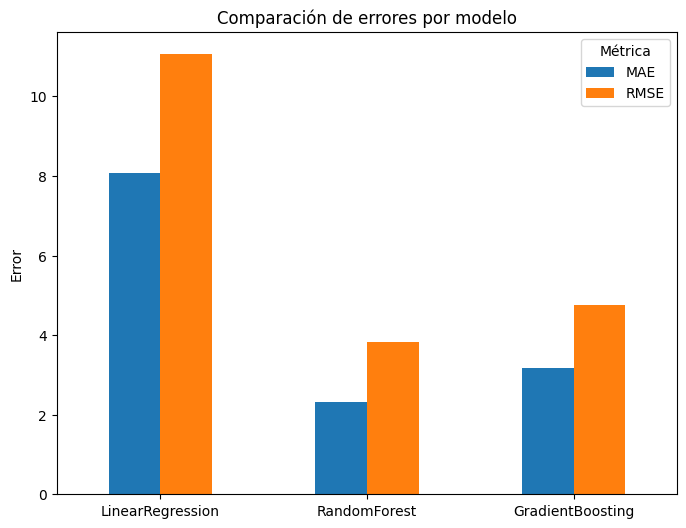

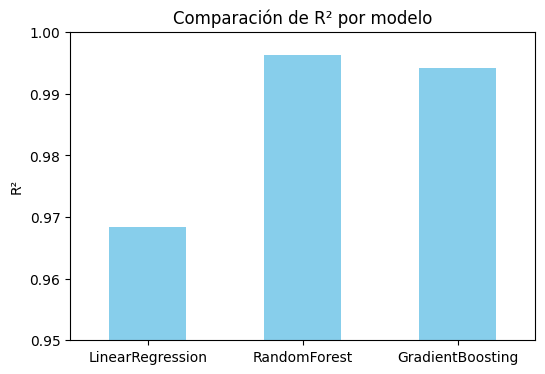

In [25]:
results_df[["MAE", "RMSE"]].plot(kind="bar", figsize=(8,6))
plt.title("Comparación de errores por modelo")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.legend(title="Métrica")
plt.show()

print("\n")
results_df["R2"].plot(kind="bar", figsize=(6,4), color="skyblue")
plt.title("Comparación de R² por modelo")
plt.ylabel("R²")
plt.ylim(0.95, 1)
plt.xticks(rotation=0)
plt.show()


En la primera gráfica se observa que la **Regresión Lineal** tiene los errores más altos (MAE y RMSE), lo que confirma que no logra capturar correctamente las relaciones entre las variables. En contraste, **Random Forest** presenta los errores más bajos, seguido de cerca por **Gradient Boosting**, lo que evidencia un mejor ajuste a los datos.  

En la segunda gráfica, el **R²** muestra qué tan bien explica cada modelo la variabilidad de los datos. Aquí, tanto **Random Forest** como **Gradient Boosting** alcanzan valores cercanos a 1 (≈ 0.996 y 0.994 respectivamente), lo que significa que casi toda la variabilidad de las calorías quemadas queda explicada por las variables de entrada. La Regresión Lineal, aunque obtiene un R² relativamente alto (≈ 0.986), se queda atrás en precisión comparado con los modelos de ensamble.  



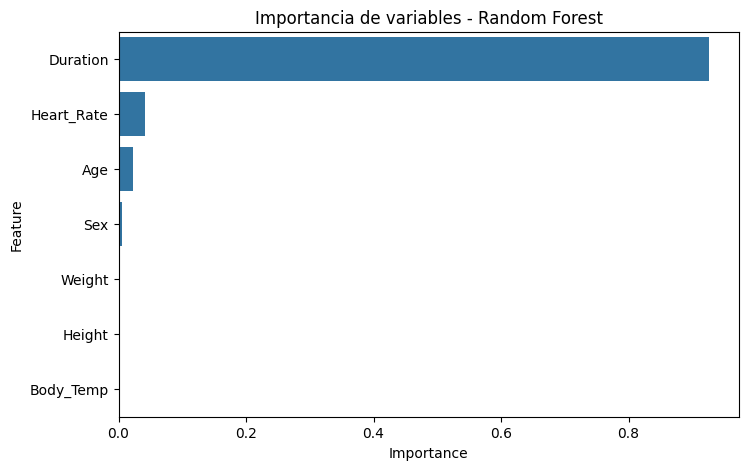

In [30]:
best_model = models["RandomForest"]

importances = best_model.feature_importances_
feature_names = X.columns

feat_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_df = feat_df.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=feat_df)
plt.title("Importancia de variables - Random Forest")
plt.show()

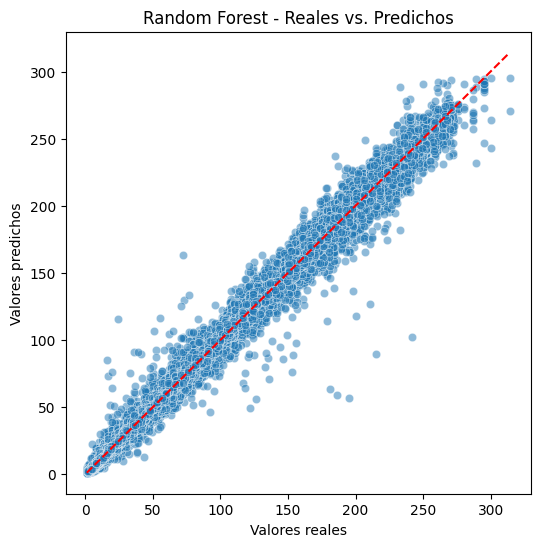

In [26]:
import seaborn as sns

y_pred_best = best_model.predict(X_val)

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_val, y=y_pred_best, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Random Forest - Reales vs. Predichos")
plt.show()

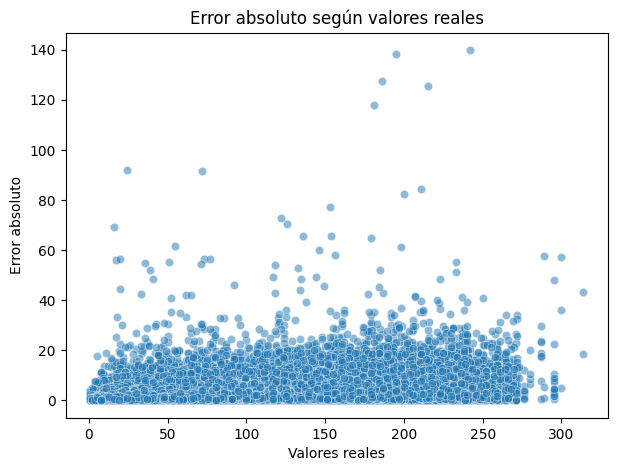

In [28]:
errors = y_val - y_pred_best
abs_errors = abs(errors)

plt.figure(figsize=(7,5))
sns.scatterplot(x=y_val, y=abs_errors, alpha=0.5)
plt.xlabel("Valores reales")
plt.ylabel("Error absoluto")
plt.title("Error absoluto según valores reales")
plt.show()

## **Conclusiones**

Variables más relevantes:
El análisis de importancia de variables mostró que las características con mayor peso en la predicción del gasto calórico son principalmente la duración del ejercicio y la frecuencia cardíaca. También influyen, aunque en menor medida, la edad y el peso del individuo.

Rendimiento del modelo y aplicabilidad:
El mejor modelo obtenido fue el Random Forest, con un R² ≈ 0.996, MAE ≈ 2.2 y RMSE ≈ 3.8. Esto significa que el modelo logra explicar casi toda la variabilidad del gasto calórico y comete un error promedio muy bajo (solo unas pocas calorías).
Gracias a su precisión y robustez, el modelo es adecuado para aplicaciones reales, como sistemas de monitoreo en dispositivos de fitness o aplicaciones móviles que estimen calorías quemadas en tiempo real.